In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def u(c, γ):
    return c**(1-γ) / (1-γ)
    

This is the best time to began our introduction into the Bellman equation and dynamic programming and we are going to generalize our value function to the basis of a Bellman equation. Our value equation works as:
$$v(x) = max_{c(t)}\sum_{i=1}^{n} \beta^t u(c_{t})$$
subject to:
$x_{t+1} = x_{t} - c_{t}$ and $  0 \leq c_{t} \leq x_{t} $.

and note $$v(x) = \max_{0 \leq c \leq x} {u(c)+\beta v(x-c)}$$

which is our Bellman equation format.

Here {c} reflects a path of consumption for our agent and the $x_{t}$ in our budget constratint reflects our state variable that consumption has to be under. The agent chooses consumption depending on the value of the state variable at time t and $\beta$ and $\gamma$ work as paramters that dictate our utility. The idea behind $\beta$ is that consumption is costly because future consumption has this discounted factor, but our $\gamma$ gives us risk aversion based on the gamma, where higher values of $\gamma$ indicate a stronger preference towards smoothing consumption in the future (aka a flatter curve). Notice in our graph below that our higher gamma values are below the graphs that have much lower gammas, which indicate an increasing amount of consumption with time.

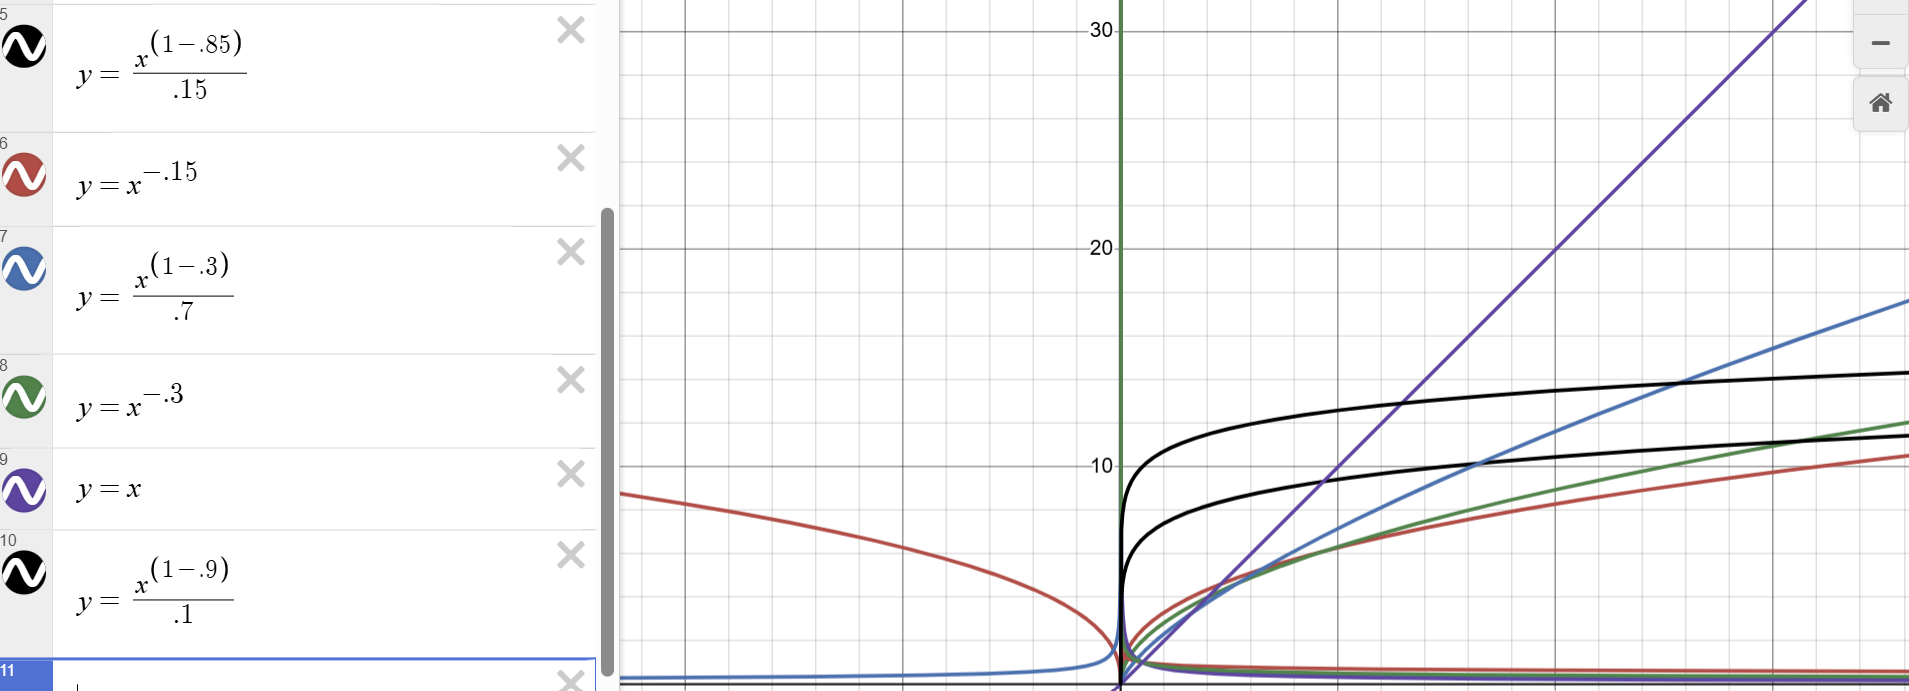

Luckily, with such a popular consumption formula we are given a simple analytical solution of 
$$v^{*}(x) = (1-\beta^\frac{1}{\gamma})^{-\gamma}u(x) $$

with $x = c$ as part of maximizing consumption

In [ ]:
def v_star(x, β, γ):

    return (1 - β**(1 / γ))**(-γ) * (x**(1-γ) / (1-γ))

β, γ = 0.95, 1.2
x_grid = np.linspace(0.1, 5, 100)

fig, ax = plt.subplots()

ax.plot(x_grid, v_star(x_grid, β, γ), label='value function')

ax.set_xlabel('$x$', fontsize=12)
ax.legend(fontsize=12)

plt.show()

We attempt to maximize the equuation on the right hand side using our optimal consumption as:

$$\sigma^{*}(x) = \max_{0 \leq c \leq x} {u(c)+\beta v(x-c)}$$

which analytically turns into

$$\sigma^{*}(x) = (1-\beta^\frac{1}{\gamma})(x) $$

Note, that our natural intuition of the parameters and our work in desmos demonstrated that increasing any of the parameters would lead to a decrease in consumption. Let's see this in action.


In [ ]:
def c_star(x, β, γ):

    return (1 - β ** (1/γ)) * x

fig, ax = plt.subplots()
ax.plot(x_grid, c_star(x_grid, β, γ), label='default parameters')
ax.plot(x_grid, c_star(x_grid, β + 0.02, γ), label=r'higher $\beta$')
ax.plot(x_grid, c_star(x_grid, β, γ + 0.2), label=r'higher $\gamma$')
ax.set_ylabel(r'$\sigma(x)$')
ax.set_xlabel('$x$')
ax.legend()

plt.show()

We now can move our discussion towards the Euler Equation. The Euler Equation explains how marginal consumption today relates to consumption in the future. That is that the amount the person values the nexy step in consuming more is equal to the discounted marginal utility of consumption in the future. That is then that at an equal $\beta = 1$ then there is perfect substitution between utility of consuming today and tomorrow and there is a perfectly stable consumption. At lower levels of $\beta$, the implication of our equation is that the marginal utility of consuming tomorrow must be higher then consuming today and thereby consumption actually decreases. Notice in our desmos work, higher marginal utility (in the lines that approach 0) all are from much lower consumption. 

$$u^{'}(c^{*}_{t}) = \beta u^{'}(c^{*}_{t+1}) $$

You'll notice, with our optimal policy notation, this equation looks closer to:

$$u^{'}(\sigma^(x)) = \beta u^{'}(\sigma(x_{t}-\sigma(x))) $$

How should we approach our Bellman Equation? Let's recall our Bellman Equation formula:
$$v(x) = \max_{0 \leq c \leq x} {u(c)+\beta v(x-c)}$$

We first take the derivative with respect to $c$ and then set our derivative to $0$.

$$u'(c) = \beta v'(x-c) $$

We can now set:
$$g(c,x) = {u(c)+\beta v(x-c)} $$

and therefore:

$$v(x) = g(c,x) $$


We can now approach the numerical part of solving for such models beyond an analytical approach.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar, bisect
from typing import NamedTuple

In [ ]:
def c_star(x, β, γ):
    return (1-β**(1/γ)*x)

def v_star(x, β, γ):

    return (1 - β**(1 / γ))**(-γ) * (x**(1-γ) / (1-γ))

Above we defined the previously given Analytical solutions to the previous cake eating problems. Not our Bellman Equation:
$$v(x) = \max_{0 \leq c \leq x} {u(c)+\beta v(x-c)}$$

We need to describe a Bellman operator $T$ such that $T$ functions as a contraction mapping onto our equation. Thereby,
$$Tv(x) = \max_{0 \leq c \leq x} {u(c)+\beta v(x-c)}$$

of which $T$ iterates through our equation to get us to our fixed point. We'll save the actual contraction mapping theorem for a seperate time or perhaps will be added into this at a later date.

When programming this numerically, we first work with a __maximizer__ function which fill take in a function $g$, and apply the minimize scalar function while setting the function as negative (turning the minimizer into a maximizing problem). We then define a Model, and a cake eating problem who's paramaters are fed into the model and returned. Then we define our standard **CRRA utility** nction.

We can then build a bellman operater equation, first defining our previous Bellman equation as a function $B$, and then the bellman operator $T$ to be applied.


In [ ]:
def maximize(g, upper_bound):
    objective = lambda x: -g(x)
    bounds = (0, upper_bound)
    result = minimize_scalar(objective, bounds = bounds, method = 'bounded')
    maximizer, minimizer = result.x, -result.fun # result. fun represents our minimum valued function 
    return maximizer, minimizer



In [ ]:
class Model(NamedTuple):
    β: float
    γ: float
    x_grid:np.ndarray

def create_cake_eating_model(
        β: float = 0.96,           # discount factor
        γ: float = 1.5,            # degree of relative risk aversion
        x_grid_min: float = 1e-3,  # exclude zero for numerical stability
        x_grid_max: float = 2.5,   # size of cake
        x_grid_size: int = 120
    ):
    
    x_grid = np.linspace(x_grid_min, x_grid_max, x_grid_size)
    return Model(β, γ, x_grid)

def u(c, γ):
    return (c**(1-γ) )/ (1-γ)

len(x_grid)
    

In [ ]:
def B(x: float,
      c: float,
      v: np.ndarray,
      model: Model
     ):

    
    β, γ, x_grid = model
    vf = lambda x: np.interp(x, x_grid, v) # This functions as an interpolation where we use x as our guess, and x_grid and V as knowns that they interpolate over.

    return u(c, γ) + β * vf(x-c)

In [ ]:
def T(v: np.ndarray,
      model: Model
     ):

    v_new = np.empty_like(v) # builds array with exact specifications to v, but with garbage data that will be overwritten

    for i, x in enumerate(model.x_grid):
        # maximizing right hand side of the Bellman equation from [0, x]
        _, v_new[i] = maximize(lambda c: B(x, c, v, model), x)

    return v_new

model = create_cake_eating_model() # notice cake eating problem already gave us our generic values,
β, γ, x_grid = model



Before we continue with our iteration, we need a solid guess for what we think our values of each of our iterations is gonna be. To do this, we will set v as an array of our grid iterated.

In [ ]:
v = u(x_grid, γ)

In [ ]:
n = 12
fig, ax = plt.subplots()

for i in range(n):
    v = T(v, model)
    ax.plot(x_grid, v, color=plt.cm.jet(i / n), lw=2, alpha=0.6)

# One last update and plot
v = T(v, model)  
ax.plot(x_grid, v, color=plt.cm.jet(0),
        lw=2, alpha=0.6, label='Final guess')

ax.legend()
ax.set_ylabel('value', fontsize=12)
ax.set_xlabel('cake size $x$', fontsize=12)
ax.set_title('Value function iterations')
plt.show()


In [ ]:
def compute_value_function(
    model: Model,
    tol: float = 1e-4,
    max_iter: int = 1_000,
    verbose: bool = True,
    print_skip: int = 25
):
    v = np.zeros(len(model.x_grid)) # guess
    i = 0

    error = tol + 1
    while i < max_iter and error > tol:
        v_new = T(v, model) # plug v in as initial guess

        error = np.max(np.abs(v - v_new))
        i += 1
        
        if verbose and i % print_skip == 0:
            print(f"Error at iteration {i} is {error}.")
            
        v = v_new

    if error > tol:
        print("Failed to converge!")
    elif verbose:
        print(f"\nConverged in {i} iterations.")

    return v_new
        
    

In [ ]:
# v = compute_value_function(model)
len(v)

In [ ]:
fig, ax = plt.subplots()

ax.plot(x_grid, v, label = 'Approximate Value Function')
ax.set_ylabel('$V(x)$', fontsize = 12)
ax.set_xlabel('$x$', fontsize = 12)
ax.set_title('Value Function')
ax.legend()
plt.show()

In [ ]:
v_analytical = v_star(x_grid, β, γ)
len(v_analytical)


fig, ax = plt.subplots()

ax.plot(x_grid, v_analytical, label='analytical solution')
ax.plot(x_grid, v, label='numerical solution')
ax.set_ylabel('$V(x)$', fontsize=12)
ax.set_xlabel('$x$', fontsize=12)
ax.legend()
ax.set_title('Comparison between analytical and numerical value functions')
plt.show()

In [ ]:
def get_greedy(
        v: np.ndarray,          # current guess of the value function
        model: Model            # instance of cake eating model
    ):
    " Compute the v-greedy policy on x_grid."

    σ = np.empty_like(v)

    for i, x in enumerate(model.x_grid):
        # Maximize RHS of Bellman equation at state x
        σ[i], _ = maximize(lambda c: B(x, c, v, model), x)

    return σ

In [ ]:
σ = get_greedy(v, model)

In [ ]:
c_analytical = c_star(model.x_grid, model.β, model.γ)

fig, ax = plt.subplots()

ax.plot(model.x_grid, c_analytical, label='analytical')
ax.plot(model.x_grid, σ, label='numerical')
ax.set_ylabel(r'$\sigma(x)$')
ax.set_xlabel('$x$')
ax.legend()

plt.show()

We now want to extend our practice of deriving Bellman Equations for such problems, but for a simple extension where we adapt how $x_{t+1}$ grows over time. Now: $x_{t+1} = (x_{t}-c_{t})^{\alpha}$ for $0\leq \alpha \leq 1$

In [ ]:
class Extended_Model(NamedTuple):
    β: float
    γ: float
    α: float
    x_grid: np.ndarray

def Extended_Cake_Model(β: float = 0.96,           # discount factor
        γ: float = 1.5,
                        α: float = 0.4, # degree of relative risk aversion
        x_grid_min: float = 1e-3,  # exclude zero for numerical stability
        x_grid_max: float = 2.5,   # size of cake
        x_grid_size: int = 120
                       ):
    x_grid = np.linspace(x_grid_min, x_grid_max, x_grid_size)
    return Extended_Model(β, γ, α, x_grid)

def extended_B(x, 
               c,
               v, 
               model):
    β, γ, α, x_grid = Model
    vf = lambda x: np.interp(x, x_grid, v)
    return u(c, γ) - vf((x-c)**α) # notice here the adjustemement in x_{t+1} lies in how we define the value function in the bellman equation

In [ ]:
def extended_T(v, model):
    " The Bellman operator for the extended cake model. "

    v_new = np.empty_like(v)
    for i, x in enumerate(model.x_grid):
        _, v_new[i] = maximize(lambda c: extended_B(c, x, v, model), x)
    return v_new
    

In [ ]:
model = Extended_Cake_Model()


In [ ]:
def compute_value_function(model,
                           tol = 1e-4,
                           max_iter = 1000,
                           verbose = True,
                           print_skip = 25):

    
    v = np.zeroes(len(model.x_grid)) # define list of zeroes for the size of the grid we work on
    i = 0
    error = tol + 1

    while error > tol and i < max_iter:
        v_new = extended_T(v, model)
        error = np.max(np.abs(v-v_new))
        i += 1

        if verbose and i % print_skip == 0:
            print (f'Error at iteration {i} is {error}.')

        if error > tol:
            print('Failed to converge')
        elif verbose:
            print(f'\nConvergence at {i} iterations')

fig, ax = plt.subplots()

ax.plot(model.x_grid, v, lw=2, alpha=0.6)
ax.set_ylabel('value', fontsize=12)
ax.set_xlabel('state $x$', fontsize=12)

plt.show()       
            
    

In [ ]:
def extended_get_greedy(model, v):
    """
    The optimal policy function for the extended cake model.
    """
    σ = np.empty_like(v)

    for i, x in enumerate(model.x_grid):
        # Maximize extended_B with respect to c over [0, x]
        σ[i], _ = maximize(lambda c: extended_B(c, x, v, model), x)

    return σ

σ = extended_get_greedy(model, v)

# Get the baseline model for comparison
baseline_model = create_cake_eating_model()
c_analytical = c_star(baseline_model.x_grid, baseline_model.β, baseline_model.γ)

fig, ax = plt.subplots()

ax.plot(baseline_model.x_grid, c_analytical, label=r'$\alpha=1$ solution')
ax.plot(model.x_grid, σ, label=fr'$\alpha={model.α}$ solution')

ax.set_ylabel('consumption', fontsize=12)
ax.set_xlabel('$x$', fontsize=12)

ax.legend(fontsize=12)

plt.show()

For some reason, coding this was a complete disaster. That being said we will move on to the stochastic return, time iteration, and most importnatly an endogenous grid choice for this problem. This will be crucial in speeding up our computation.

We will begin this section with trying to understand the stochastic return. Best to understand now that stochastic returns are simply a sequence of random variables.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from typing import NamedTuple, Callable

Let's consider an agent who owns $x_{t} := [0, \infty) $ of a particular consumption good at time t. At time t, they have a choice of either consuming or saving the goods they have. At the end of each period, they will experience a shock $\xi_{t+1}$. Thereby, next period output will be defined as:

$$x_{t+1} := f(s_{t})\xi_{t+1}, f:\mathbb{R}_{+} \to \mathbb{R}_{+}$$
where $s_{t}$ is denoted as $s_{t} := x_{t} - c_{t} $ as current savings

Our maximization condition works as:

$$\mathbb{E}\sum_{i=1}^{\infty} \beta^{t}u(c_{t})$$

subject to:

$$x_{t+1} = f(x_{t} - c_{t}) \xi_{t+1}$$ and $$    0 \leq c_{t} \leq x_{t} $$

Again, we should understand $x_{t}$ as a state variable describing the condition of income, while $c_{t}$ is like your control variable and is about what you can do.

Note again, that we have our optimatl policy $0 \leq \sigma(x) \leq x$, which thereby must respect our resource constraint. To understand our $\sigma(x)$ as a Markov Dynamic for $x_{t}$ lets go forward and work through some understanding of Markov Dynamics.

In [ ]:
import matplotlib.pyplot as plt
import quantecon as qe
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

We first need to build up a notion of Stochastic Matrices. A stochastic matrix is defined as an $n \times n$ square matrix $P$ s.t 
1). Each Element of P is nonnegative
2). Each row of P sums up to 1

We should think of each row as the PMF of a discrete Random Variable in this case of finite Markov Chains. Now for the State space $S$ with state variables $[x_{1}, x_{2}, ..... , x_{n}]$. The Markov chain $[{X_{t}}]$ on $S$ is the sequence of random variables that have the markov property: That for any date t, and any state y in S, then knowing the current state allows you to write the probabilities for all points after t.

We should note then that chain is written as:
$$P(x,y):= \mathbb{P}[X_{t+1} = y | X_{t} = x]$$ which is defined as moving from one step to the next. 

For our $P$ matrix, we can say 
$$P(x_{i}, x_{j}) = P_{i,j} $$

We should note then that: $P(x, *)$ which will serve as the conditional distribution of $X_{t+1} for X_{t} = x$ which will show us the probabilistic space of potential $Y $values that for each period, the agent will 'draw from'.


Let's go through an example. Consider a worker is either unemployed (0) or employed (1). We can define their state space as $$S:= [0,1]$$
with $$P(0,1) = \alpha $$ and $$P(1,0) = \beta$$. Which essentially means the probability of going from unemployed to employed is $\alpha$ and the probability of going from employed to unemployed is $\beta$ for alpha and beta both as elements of the set [0,1]

Let's consider a more applied case. We have a matrix $$
\begin{bmatrix}
0.971 & 0.029 & 0 \\
0.145 & 0.778 & 0.077 \\
0 & 0.508 & 0.492
\end{bmatrix}
$$

Here which represents our states of a country as it goes through standard business cycles. The first state here represents normal growth, while the second represents a mild recessions, and the third is a severe recession. This is a more illustrative example of state and transitions and you should reference Quant ECOn to relate this to an actual diagram

In [ ]:
ψ = (0.3, 0.7)           # probabilities over {0, 1}
cdf = np.cumsum(ψ)       # convert into cummulative distribution
qe.random.draw(cdf, 5)   # generate 5 independent draws from ψ

We now move on to building our markov chain, we drew a random array of 1,0 for which we will set up our markov chain

In [ ]:
def mc_sample_path(P, ϕ_0 = None, sample_size = 1_000):

    P = np.asarray(P)
    X = np.empty(sample_size, dtype = int)

    n = len(P)
    P_dist = [np.cumsum(P[i,:]) for i in range(n)]
    if ϕ_0 is not None:
        X_0 = qe.random.draw(np.cumsum(ϕ_0))
    else:
        X_0 = 0

    X[0] = X_0
    for t in range(sample_size - 1):
        X[t+1] = qe.random.draw(P_dist[X[t]])

    return X

In [ ]:
P = [[0.4, 0.6],
     [0.2, 0.8]]

X = mc_sample_path(P, ϕ_0=[0.1, 0.9], sample_size=100_000)
np.mean(X == 0)

I feel fine stopping around here in our explanation of Markov Dynamics. Here we can understand the optimal policy for $\sigma \in \Sigma$ for our put $[x_{t}]$ via:
$$x_{t+1} = f(x_{t} -\sigma(x_{t}))\xi_{t+1}$$

and we can treat the optimal policy subsituting $c_{t} = \sigma(x_{t})$ as equivalent and thereby,
$t})


I feel fine stopping around here in our explanation of Markov Dynamics. Here we can understand the optimal policy for $\sigma \in \Sigma$ for our put $[x_{t}]$ via:
$$x_{t+1} = f(x_{t} -\sigma(x_{t}))\xi_{t+1}$$
and we can treat the optimal policy subsituting $c_{t} = \sigma(x_{t})$ as equivalent and thereby,
$$v_{\sigma}(x) = \mathbb{E}\sum_{i=0}^{\infty}\beta^{t}u(\sigma(x_{t}))$$

While this may be our theoretical notion, we should understand the true functional form of our Equation:

$$v(x) = \max_{0 \leq c \leq x} [u(c) + \beta \int v(f(x-c)z)\phi(dz)] $$

of which $\int v(f(x-c)z)\phi(dz)$ is the value of the next period

We will now work to compute the problem through programming. Note that I left part of this incomplete, however it should make general sense based on our previous reviews.

In [ ]:
def maximize(g, upperbound):
    objective = lambda c: -g(c)
    bounds = (0, upperbound)
    result = minimize_scalar(objective, bounds=bounds, method='bounded')
    maximizer, maximum = result.x, -result.fun
    return maximizer, maximum
    
class Model(NamedTuple):
    u: Callable        # utility function
    f: Callable        # production function
    β: float           # discount factor
    μ: float           # shock location parameter
    ν: float           # shock scale parameter
    x_grid: np.ndarray # state grid
    shocks: np.ndarray # shock draws


def create_model(
        u: Callable,
        f: Callable,
        β: float = 0.96,
        μ: float = 0.0,
        ν: float = 0.1,
        grid_max: float = 4.0,
        grid_size: int = 120,
        shock_size: int = 250,
        seed: int = 1234
    ) -> Model:
    """
    Creates an instance of the optimal savings model.
    """
    # Set up grid
    x_grid = np.linspace(1e-4, grid_max, grid_size)

    # Store shocks (with a seed, so results are reproducible)
    rng = np.random.default_rng(seed)
    shocks = np.exp(μ + ν * rng.standard_normal(shock_size))

    return Model(u, f, β, μ, ν, x_grid, shocks)

We defined our shock as an exponent of $exp(\mu + v \zeta)$ for some standard normal value distributed. We then wrote down our model as id and then created our bellman operator as an interpolation of x_grd, and x_array and we interpret this through our equation. You may notice as well that our integral simplied to a mean, which was approximated via a monte carlo.

In [ ]:
def B(
        x: float,              # State
        c: float,              # Action
        v_array: np.ndarray,   # Array representing a guess of the value fn
        model: Model           # An instance of Model containing parameters
    ):

    u, f, β, μ, ν, x_grid, shocks = model
    v = interp1d(x_grid, v_array)

    return u(c) + β * np.mean(v(f(x - c) * shocks))

In [ ]:
def T(v: np.ndarray, model: Model) -> tuple[np.ndarray, np.ndarray]:

    x_grid = model.x_grid
    v_new = np.empty_like(v)

    for i in range(len(x_grid)):
        x = x_grid[i]
        _, v_max = maximize(lambda c: B(x,c,v, model), x)
        v_new[i] = v_max

    return v_new

In [ ]:
def get_greedy(
        v: np.ndarray,          # current guess of the value function
        model: Model            # instance of optimal savings model
    ):
    " Compute the v-greedy policy on x_grid."

    σ = np.empty_like(v)

    for i, x in enumerate(model.x_grid):
        # Maximize RHS of Bellman equation at state x
        σ[i], _ = maximize(lambda c: B(x, c, v, model), x)

    return σ

In [ ]:
def v_star(x, α, β, μ):
    """
    True value function
    """
    c1 = np.log(1 - α * β) / (1 - β)
    c2 = (μ + α * np.log(α * β)) / (1 - α)
    c3 = 1 / (1 - β)
    c4 = 1 / (1 - α * β)
    return c1 + c2 * (c3 - c4) + c4 * np.log(x)

def σ_star(x, α, β):
    """
    True optimal policy
    """
    return (1 - α * β) * x

In [ ]:
α = 0.4
def fcd(s):
    return s**α

model = create_model(u=np.log, f=fcd)

x_grid = model.x_grid

v_init = v_star(x_grid, α, model.β, model.μ)    # Start at the solution
v = T(v_init, model)             # Apply T once

fig, ax = plt.subplots()
ax.set_ylim(-35, -24)
ax.plot(x_grid, v, lw=2, alpha=0.6, label='$Tv^*$')
ax.plot(x_grid, v_init, lw=2, alpha=0.6, label='$v^*$')
ax.legend()
plt.show()

In [ ]:
v = 5 * np.log(x_grid)  # An initial condition
n = 35

fig, ax = plt.subplots()

ax.plot(x_grid, v, color=plt.cm.jet(0),
        lw=2, alpha=0.6, label='Initial condition')

for i in range(n):
    v = T(v, model)  # Apply the Bellman operator
    ax.plot(x_grid, v, color=plt.cm.jet(i / n), lw=2, alpha=0.6)

ax.plot(x_grid, v_star(x_grid, α, model.β, model.μ), 'k-', lw=2,
        alpha=0.8, label='True value function')

ax.legend()
ax.set(ylim=(-40, 10), xlim=(np.min(x_grid), np.max(x_grid)))
plt.show()

In [ ]:
def solve_model(
        model: Model,           # instance of optimal savings model
        tol: float = 1e-4,      # convergence tolerance
        max_iter: int = 1000,   # maximum iterations
        verbose: bool = True,   # print iteration info
        print_skip: int = 25    # iterations between prints
    ):
    " Solve by value function iteration. "

    v = model.u(model.x_grid)  # Initial condition
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:
        v_new = T(v, model)
        error = np.max(np.abs(v - v_new))
        i += 1
        if verbose and i % print_skip == 0:
            print(f"Error at iteration {i} is {error}.")
        v = v_new

    if error > tol:
        print("Failed to converge!")
    elif verbose:
        print(f"\nConverged in {i} iterations.")

    v_greedy = get_greedy(v_new, model)
    return v_greedy, v_new

In [ ]:
v_greedy, v_solution = solve_model(model)

In [ ]:
fig, ax = plt.subplots()

ax.plot(x_grid, v_solution, lw=2, alpha=0.6,
        label='Approximate value function')

ax.plot(x_grid, v_star(x_grid, α, model.β, model.μ), lw=2,
        alpha=0.6, label='True value function')

ax.legend()
ax.set_ylim(-35, -24)
plt.show()

In [ ]:
fig, ax = plt.subplots()

ax.plot(x_grid, v_greedy, lw=2,
        alpha=0.6, label='approximate policy function')

ax.plot(x_grid, σ_star(x_grid, α, model.β), '--',
        lw=2, alpha=0.6, label='true policy function')

ax.legend()
plt.show()

In [ ]:
# solving for the practice problem

γ = 1.5
def u_crra(c):
    (c**(1-γ)) / (1-γ)

model = create_model(u=u_crra, f= fcd)

v_greedy, v_solution = solve_model(model)

This also appears to be a slight disaster but we will keep going regardless. We know want to try and approach some of Mcgrattan's Early computational Homework and see how good we fair.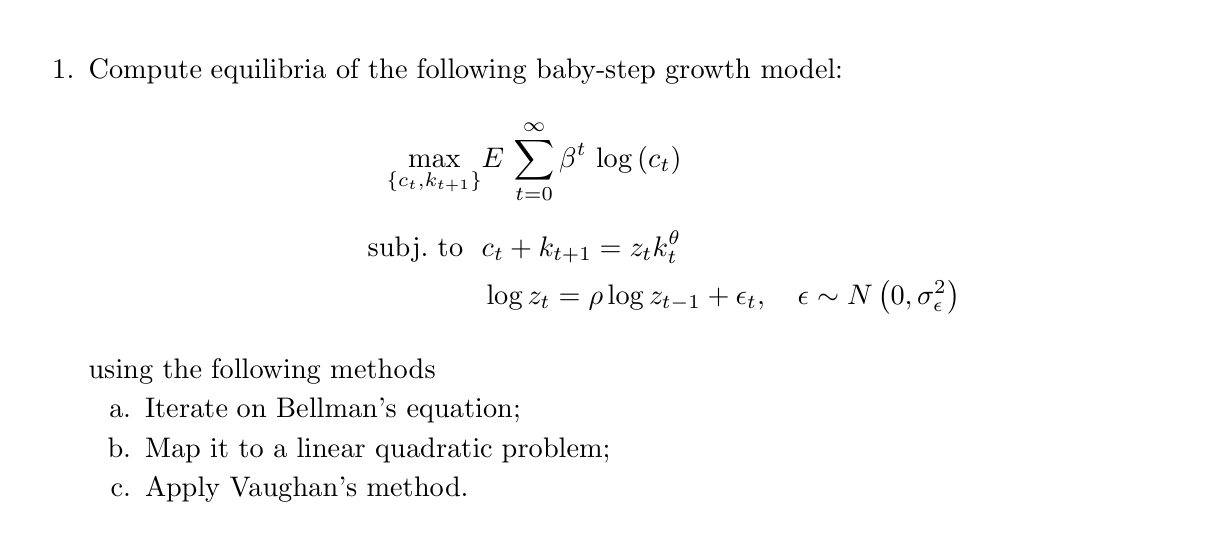 We have this model that we will try to solve in Mcgrattan's First Grade Homework. We already have a good base understanding of how this will work via the work done in Quantecon. Let's first redefine the consumer model via the RAmsey cass koopmas model

In [ ]:
import matplotlib.pyplot as plt
from numba import jit, float64
from numba.experimental import jitclass
import numpy as np
from quantecon.optimize import brentq


We follow a similar structure in the development of the represententative household, where in this case we are using a household with CRRA utility. This is most similar to our Dirk Krueger Model where we have a Cobb Douglas Production function for our total production in the economy  and a feasible allocation satisfies our standard budget constraint. Written out:
$$U(C) = \sum_{t=0}^{T}\beta^{t}\frac{C^{1-\gamma}_{t}}{1-\gamma}$$ for
$$F(K_{t}, N_{t}) = K_{t}^{\alpha}N_{t}^{1-\alpha} $$
of which a feasible allocation is defined as:
$$C_{t} + K_{t+1} \leq F(K_{t}, N_{t}) + (1-\delta)K_{t} $$

In [ ]:
planning_data = [
    ('γ', float64),    # Coefficient of relative risk aversion
    ('β', float64),    # Discount factor
    ('δ', float64),    # Depreciation rate on capital
    ('α', float64),    # Return to capital per capita
    ('A', float64)     # Technology
] # We set this out as our parameers for our model that are not our direct inputs like K_t and N_t and 

In [ ]:
@jitclass(planning_data)
class PlanningProblem():

    def __init__(self, γ=2, β=0.95, δ=0.02, α=0.33, A=1):

        self.γ, self.β = γ, β
        self.δ, self.α, self.A = δ, α, A

    def u(self, c):
        '''
        Utility function
        ASIDE: If you have a utility function that is hard to solve by hand
        you can use automatic or symbolic differentiation
        See https://github.com/HIPS/autograd
        '''
        γ = self.γ

        return c ** (1 - γ) / (1 - γ) if γ!= 1 else np.log(c)

    def u_prime(self, c):
        'Derivative of utility'
        γ = self.γ

        return c ** (-γ)

    def u_prime_inv(self, c):
        'Inverse of derivative of utility'
        γ = self.γ

        return c ** (-1 / γ)

    def f(self, k):
        'Production function'
        α, A = self.α, self.A

        return A * k ** α

    def f_prime(self, k):
        'Derivative of production function'
        α, A = self.α, self.A

        return α * A * k ** (α - 1)

    def f_prime_inv(self, k):
        'Inverse of derivative of production function'
        α, A = self.α, self.A

        return (k / (A * α)) ** (1 / (α - 1))

    def next_k_c(self, k, c):
        ''''
        Given the current capital Kt and an arbitrary feasible
        consumption choice Ct, computes Kt+1 by state transition law
        and optimal Ct+1 by Euler equation.
        '''
        β, δ = self.β, self.δ
        u_prime, u_prime_inv = self.u_prime, self.u_prime_inv
        f, f_prime = self.f, self.f_prime

        k_next = f(k) + (1 - δ) * k - c
        c_next = u_prime_inv(u_prime(c) / (β * (f_prime(k_next) + (1 - δ))))

        return k_next, c_next
        
        

In [ ]:
pp = PlanningProblem()

In [ ]:
@jit
def shooting(pp, c0, k0, T=10):
    if c0 > pp.f(k0) + (1 - pp.δ) * k0:
        print('initial consumption is outside feasible budget constraint')
        return None

    c_vec = np.empty(T+1)
    k_vec = np.empty(T+2)      # fixed: T+2, to hold k_0 ... k_{T+1}

    c_vec[0] = c0
    k_vec[0] = k0

    for t in range(T):
        k_vec[t+1], c_vec[t+1] = pp.next_k_c(k_vec[t], c_vec[t])

    k_vec[T+1] = pp.f(k_vec[T]) + (1 - pp.δ) * k_vec[T] - c_vec[T]   # fixed: k_vec[T], not k_vec[t]

    return c_vec, k_vec

In [ ]:
paths = shooting(pp, 0.2, 0.3, T=10)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

colors = ['blue', 'red']
titles = ['Consumption', 'Capital']
ylabels = ['$c_t$', '$k_t$']

T = paths[0].size - 1
for i in range(2): #  
    axs[i].plot(paths[i], c=colors[i])
    axs[i].set(xlabel='t', ylabel=ylabels[i], title=titles[i])

axs[1].scatter(T+1, 0, s=80)
axs[1].axvline(T+1, color='k', ls='--', lw=1)

plt.show()

In [ ]:
@jit
def bisection(pp, c0, k0, T=10, tol=1e-4, max_iter=500, k_ter=0, verbose=True):

    # initial boundaries for guess c0
    c0_upper = pp.f(k0) + (1 - pp.δ) * k0  
    c0_lower = 0

    i = 0
    while True:
        c_vec, k_vec = shooting(pp, c0, k0, T)
        error = k_vec[-1] - k_ter

        # check if the terminal condition is satisfied
        if np.abs(error) < tol:
            if verbose:
                print('Converged successfully on iteration ', i+1)
            return c_vec, k_vec

        i += 1
        if i == max_iter:
            if verbose:
                print('Convergence failed.')
            return c_vec, k_vec

        # if iteration continues, updates boundaries and guess of c0
        if error > 0:
            c0_lower = c0
        else:
            c0_upper = c0

        c0 = (c0_lower + c0_upper) / 2

In [ ]:
def plot_paths(pp, c0, k0, T_arr, k_ter=0, k_ss=None, axs=None):

    if axs is None:
        fix, axs = plt.subplots(1, 3, figsize=(16, 4))
    ylabels = ['$c_t$', '$k_t$', r'$\mu_t$']
    titles = ['Consumption', 'Capital', 'Lagrange Multiplier']

    c_paths = []
    k_paths = []
    for T in T_arr:
        c_vec, k_vec = bisection(pp, c0, k0, T, k_ter=k_ter, verbose=False)
        c_paths.append(c_vec)
        k_paths.append(k_vec)

        μ_vec = pp.u_prime(c_vec)
        paths = [c_vec, k_vec, μ_vec]

        for i in range(3):
            axs[i].plot(paths[i])
            axs[i].set(xlabel='t', ylabel=ylabels[i], title=titles[i])

        # Plot steady state value of capital
        if k_ss is not None:
            axs[1].axhline(k_ss, c='k', ls='--', lw=1)

        axs[1].axvline(T+1, c='k', ls='--', lw=1)
        axs[1].scatter(T+1, paths[1][-1], s=80)

    return c_paths, k_paths

In [ ]:
plot_paths(pp, 0.3, 0.3, [10]);
